# Earth Observation

## Supporting Information
1. Image Size: 128×128 pixels
2. Resolution: 10m/pixel (Sentinel-2 RGB)
3. CRS for Gridding: EPSG:32644
4. Label Source: ESA WorldCover 2021 (land_cover.tif, 10m resolution)
5. Visualization SDK: Use geemap.Map().add_basemap("SATELLITE")

## Q1. Spatial Reasoning & Data Filtering 
1. Plot the Delhi-NCR shapefile using matplotlib and overlay a 60×60 km uniform grid 
2. Filter satellite images whose center coordinates fall inside the region.
3. Report the total number of images before and after filtering.

In [ ]:
import os
import math
import geopandas as gpd
from shapely.geometry import box, Point
import matplotlib.pyplot as plt
import pandas as pd

In [83]:
NCR_SHAPEFILE = "data/delhi_ncr_region.geojson"
NCR_GDF = gpd.read_file(NCR_SHAPEFILE)

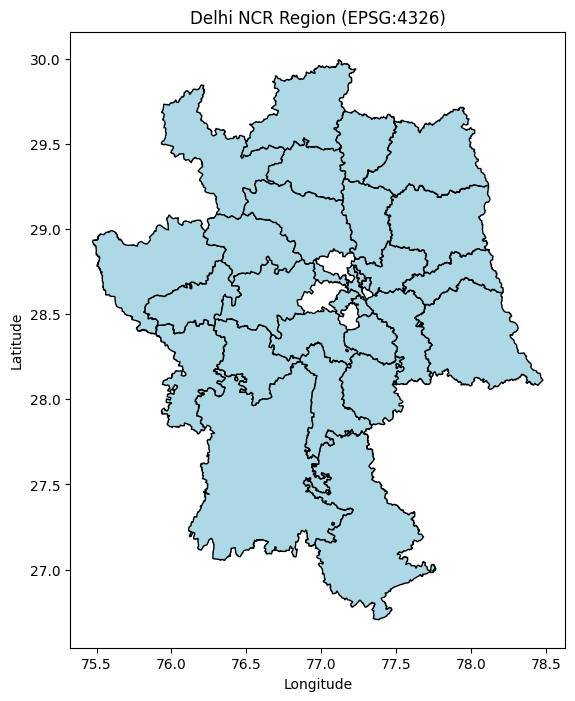

In [115]:
fig, ax = plt.subplots(figsize=(8,8))

NCR_GDF.plot(ax=ax, edgecolor="black", facecolor="lightblue")

ax.set_title("Delhi NCR Region (EPSG:4326)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [ ]:
# xyz_gdf --> EPSG:4326
# xyz_gdf_proj --> EPSG:32644

In [85]:
print("Shapefile CRS:", NCR_GDF.crs)

if NCR_GDF.crs is None:
    print("CRS is not defined. Setting to EPSG:4326.")
    NCR_GDF.set_crs(epsg=4326, inplace=True)

ncr_proj = NCR_GDF.to_crs(epsg=32644)
print("Projected CRS:", ncr_proj.crs)

Shapefile CRS: EPSG:4326
Projected CRS: EPSG:32644


In [86]:
cell_size = 60000       # 60 km in meters
minx, miny, maxx, maxy = ncr_proj.total_bounds

cols = list(range(int(math.floor(minx)), int(math.ceil(maxx)), cell_size))
rows = list(range(int(math.floor(miny)), int(math.ceil(maxy)), cell_size))

grid_cells = []

for x in cols:
    for y in rows:
        # corners.append({"grid_id": f"grid_{x}_{y}", "geometry": Point(x, y)})
        
        x1 = x + cell_size
        y1 = y + cell_size

        cell = box(x, y, x1, y1)
        grid_cells.append(cell)

grid_gdf_proj = gpd.GeoDataFrame({'geometry': grid_cells}, crs="EPSG:32644")
grid_gdf_proj = grid_gdf_proj[grid_gdf_proj.intersects(ncr_proj.union_all())].reset_index(drop=True)

# grid_gdf_proj.to_crs(epsg=4326, inplace=True)

In [110]:
all_corners = []
for idx, row in grid_gdf_proj.iterrows():
    minx, miny, maxx, maxy = row.geometry.bounds
    corners = [(minx,miny),(minx,maxy),(maxx,maxy),(maxx,miny)]
    for c in corners:
        all_corners.append({"grid_id": idx, "geometry": Point(c)})

corners_gdf_proj = gpd.GeoDataFrame(all_corners, crs="EPSG:32644")
grid_gdf_proj.head()

,geometry
0,"POLYGON ((20864 2958988, 20864 3018988, -39136..."
1,"POLYGON ((20864 3018988, 20864 3078988, -39136..."
2,"POLYGON ((20864 3078988, 20864 3138988, -39136..."
3,"POLYGON ((20864 3138988, 20864 3198988, -39136..."
4,"POLYGON ((20864 3198988, 20864 3258988, -39136..."


In [97]:
print("Number of grid cells:", len(grid_gdf_proj))

Number of grid cells: 29


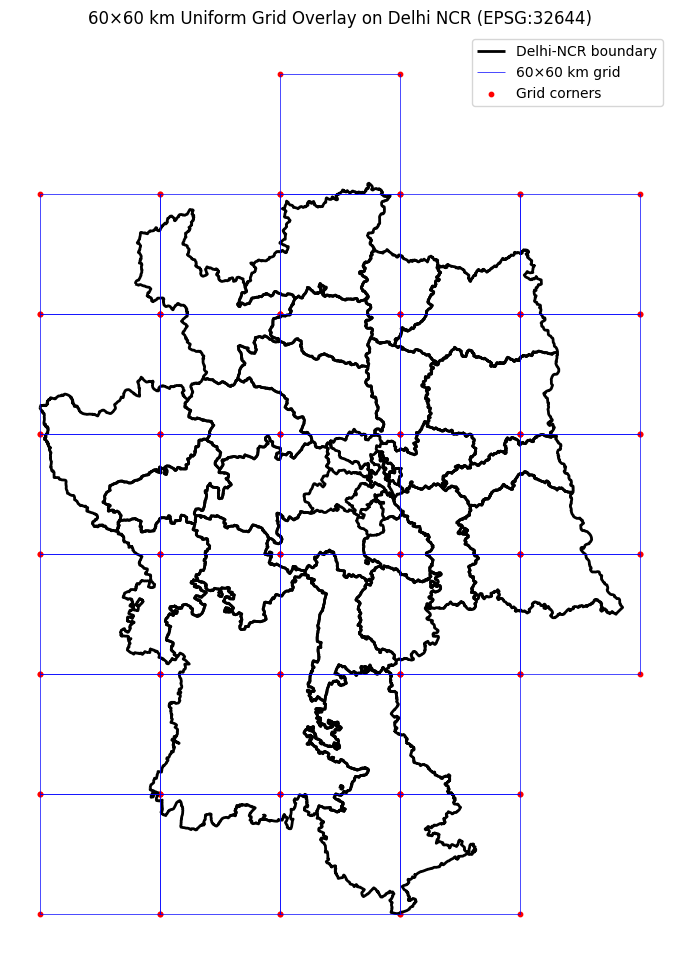

In [ ]:
fig, ax = plt.subplots(figsize=(12,12))

ncr_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=2, label="Delhi-NCR boundary")
grid_gdf_proj.boundary.plot(ax=ax, edgecolor='blue', linewidth=0.5, label="60×60 km grid")

corners_gdf_proj.plot(ax=ax, color='red', markersize=10, label="Grid corners")

ax.set_axis_off()
ax.set_title("60×60 km Uniform Grid Overlay on Delhi NCR (EPSG:32644)")
ax.legend()
plt.show()

## should i also plot in map using geemap.Map().add_basemap("SATELLITE") 
## as mentioned in the supporting information?

In [99]:
rgb_folder = "data/rgb/"
rgb_files = [f for f in os.listdir(rgb_folder) if f.endswith(".png")]
print(f"RGB files: {rgb_files[:5]}")

RGB files: ['28.2056_76.8558.png', '28.2056_76.8646.png', '28.2056_76.8734.png', '28.2056_76.8822.png', '28.2056_76.8910.png']


In [100]:
img = []

for f in rgb_files:
    lat_lon = f.replace(".png", "").split("_")          # lat_lon.png -> ["lat", "lon"]

    lat = float(lat_lon[0])
    lon = float(lat_lon[1])

    img.append({"filename": f, "latitude": lat, "longitude": lon})

images_df = pd.DataFrame(img)
images_df.head()

,filename,latitude,longitude
0,28.2056_76.8558.png,28.2056,76.8558
1,28.2056_76.8646.png,28.2056,76.8646
2,28.2056_76.8734.png,28.2056,76.8734
3,28.2056_76.8822.png,28.2056,76.8822
4,28.2056_76.8910.png,28.2056,76.8910


In [101]:
# save to csv
images_df.to_csv("image_centers.csv", index=False)

In [102]:
num_before = len(images_df)
print(f"Total images saved before filtering: {num_before}")

Total images saved before filtering: 9216


In [127]:

img_gdf = gpd.GeoDataFrame(images_df.copy(), 
                           geometry=gpd.points_from_xy(images_df.longitude, images_df.latitude), 
                           crs="EPSG:4326")

img_gdf_proj = img_gdf.to_crs(epsg=32644)

# Merge NCR polygons into one geometry
ncr_polygon = ncr_proj.union_all()

# Check if image centers lie inside NCR
inside_mask = img_gdf_proj.geometry.within(ncr_polygon)

# Filter images
filtered_images_gdf = img_gdf[inside_mask.values].reset_index(drop=True)

num_after = len(filtered_images_gdf)

In [124]:
print("Number of images before filtering:", num_before)
print("Number of images after filtering (centers fall in grid):", num_after)

Number of images before filtering: 9216
Number of images after filtering (centers fall in grid): 8015


In [125]:
filtered_out_csv = "filtered_images.csv"
filtered_images_gdf.to_csv(filtered_out_csv, index=False)
print("Filtered image metadata saved to:", filtered_out_csv)

filtered_images_gdf_proj = filtered_images_gdf.to_crs(epsg=32644)

Filtered image metadata saved to: filtered_images.csv


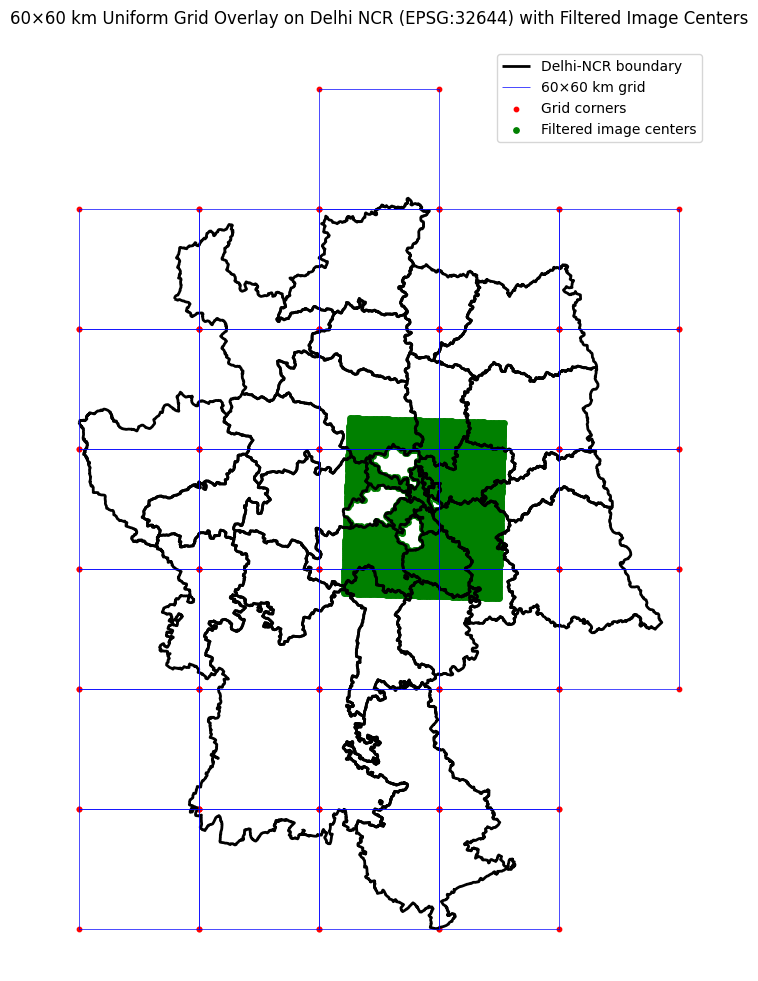

In [126]:
fig, ax = plt.subplots(figsize=(12,12))

ncr_proj.boundary.plot(ax=ax, edgecolor='black', linewidth=2, label="Delhi-NCR boundary")
grid_gdf_proj.boundary.plot(ax=ax, edgecolor='blue', linewidth=0.5, label="60×60 km grid")

corners_gdf_proj.plot(ax=ax, color='red', markersize=10, label="Grid corners")
filtered_images_gdf_proj.plot(ax=ax, color='green', markersize=15, label="Filtered image centers")

ax.set_axis_off()
ax.set_title("60×60 km Uniform Grid Overlay on Delhi NCR (EPSG:32644) with Filtered Image Centers")
ax.legend()
plt.show()

## Q2. Label Construction & Dataset Preparation
1. For each image, extract the  128×128 corresponding land-cover patch from land_cover.tif using its center coordinate 
2. Assign the image label using the dominant (mode) land-cover class.
3. Map ESA class codes to simplified land-use categories (e.g., Built-up, Vegetation, Water, Cropland, Others).
4. Perform a 60/40 train-test split randomly and visualize class distribution

In [191]:
import os
import math
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import Window
from rasterio.transform import Affine
from shapely.geometry import Point
import matplotlib.pyplot as plt
from collections import Counter
import random
from sklearn.model_selection import train_test_split
import json

In [130]:
FILTERED_CSV = "filtered_images.csv"
WORLD_COVER_TIF = "data/worldcover_bbox_delhi_ncr_2021.tif"

PATCH_PIXELS = 128
SENTINEL_RES_METERS = 10
PATCH_SIZE_METERS = PATCH_PIXELS * SENTINEL_RES_METERS

In [176]:
df_images = pd.read_csv(FILTERED_CSV)

gdf_images = gpd.GeoDataFrame(
    df_images,
    geometry=gpd.points_from_xy(df_images.longitude, df_images.latitude),
    crs="EPSG:4326"
)

print("Total filtered images:", len(gdf_images))

Total filtered images: 8015


In [175]:
gdf_images.head()

,filename,latitude,longitude,geometry
0,28.2056_76.8558.png,28.2056,76.8558,POINT (76.8558 28.2056)
1,28.2056_76.8646.png,28.2056,76.8646,POINT (76.8646 28.2056)
2,28.2056_76.8734.png,28.2056,76.8734,POINT (76.8734 28.2056)
3,28.2056_76.8822.png,28.2056,76.8822,POINT (76.8822 28.2056)
4,28.2056_76.8910.png,28.2056,76.8910,POINT (76.891 28.2056)


In [196]:
raster = rasterio.open(WORLD_COVER_TIF)
raster_img = raster.read()   # shape: (bands, height, width)
raster_img.shape

(1, 9600, 9602)

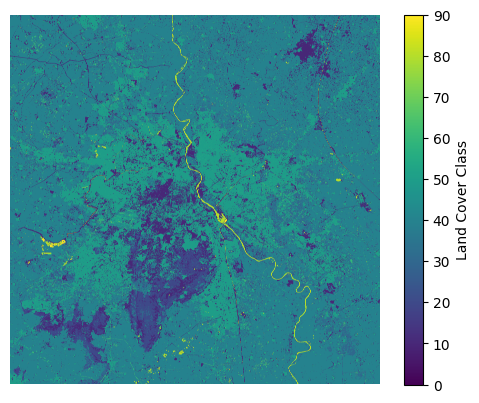

In [ ]:
raster_img = raster_img.transpose(1,2,0)  # shape: (height, width, bands)
plt.imshow(raster_img)
plt.colorbar(label="Land Cover Class")
plt.axis("off")
plt.show()

In [195]:
print("Raster CRS:", raster.crs)
print("Raster shape:", raster.width, raster.height)

Raster CRS: EPSG:4326
Raster shape: 9602 9600


In [190]:
values, counts = np.unique(img, return_counts=True)

class_counts = dict(zip(values.tolist(), counts.tolist()))
print("ESA WorldCover Class Distribution:", json.dumps(class_counts, indent=2))

ESA WorldCover Class Distribution: {
  "0": 19200,
  "10": 9595025,
  "20": 3073217,
  "30": 6558691,
  "40": 49313882,
  "50": 21435664,
  "60": 1547683,
  "80": 599996,
  "90": 35842
}


In [140]:
esa_to_label = {
    10: "Tree_cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare_sparse_veg",
    70: "Snow_ice",
    80: "Perm_water",
    90: "Herbaceous_wetland",
    95: "Mangroves",
    100: "Moss_lichen"
}

In [197]:
def extract_patch_mode(raster_ds, x_center, y_center):

    col_center, row_center = raster_ds.index(x_center, y_center)

    half = PATCH_PIXELS // 2

    window = Window(
        col_center - half,
        row_center - half,
        PATCH_PIXELS,
        PATCH_PIXELS
    )

    arr = raster_ds.read(1, window=window, boundless=True, fill_value=0)

    flat = arr.flatten()

    valid = flat[flat != 0]

    if len(valid) == 0:
        return None

    unique, counts = np.unique(valid, return_counts=True)

    mode_class = unique[np.argmax(counts)]

    return int(mode_class), counts.max()

In [198]:
records = []

for idx, row in gdf_images.iterrows():

    fname = row["filename"]

    x, y = row.geometry.x, row.geometry.y

    esa_class, max_count = extract_patch_mode(raster, x, y)

    if esa_class is None:
        label = "Other"
    else:
        label = esa_to_label.get(esa_class, "Other")

    records.append({
        "filename": fname,
        "latitude": row.geometry.y,
        "longitude": row.geometry.x,
        "esa_class": esa_class,
        "label": label,
        "class_count": max_count
    })

df_labels = pd.DataFrame(records)

print("Total labeled samples:", len(df_labels))
df_labels.head()

Total labeled samples: 8015


,filename,latitude,longitude,esa_class,label,class_count
0,28.2056_76.8558.png,28.2056,76.8558,50,Built-up,6614
1,28.2056_76.8646.png,28.2056,76.8646,40,Cropland,6375
2,28.2056_76.8734.png,28.2056,76.8734,40,Cropland,7667
3,28.2056_76.8822.png,28.2056,76.8822,40,Cropland,5891
4,28.2056_76.8910.png,28.2056,76.8910,40,Cropland,7148


In [199]:
df_labels.to_csv("dataset_labels.csv", index=False)

print("Saved labeled dataset.")

Saved labeled dataset.


In [200]:
train_df, test_df = train_test_split(
    df_labels,
    test_size=0.4,
    random_state=42,
    stratify=df_labels["label"]             # stratify to maintain class distribution in train/test splits
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 4809
Test size: 3206


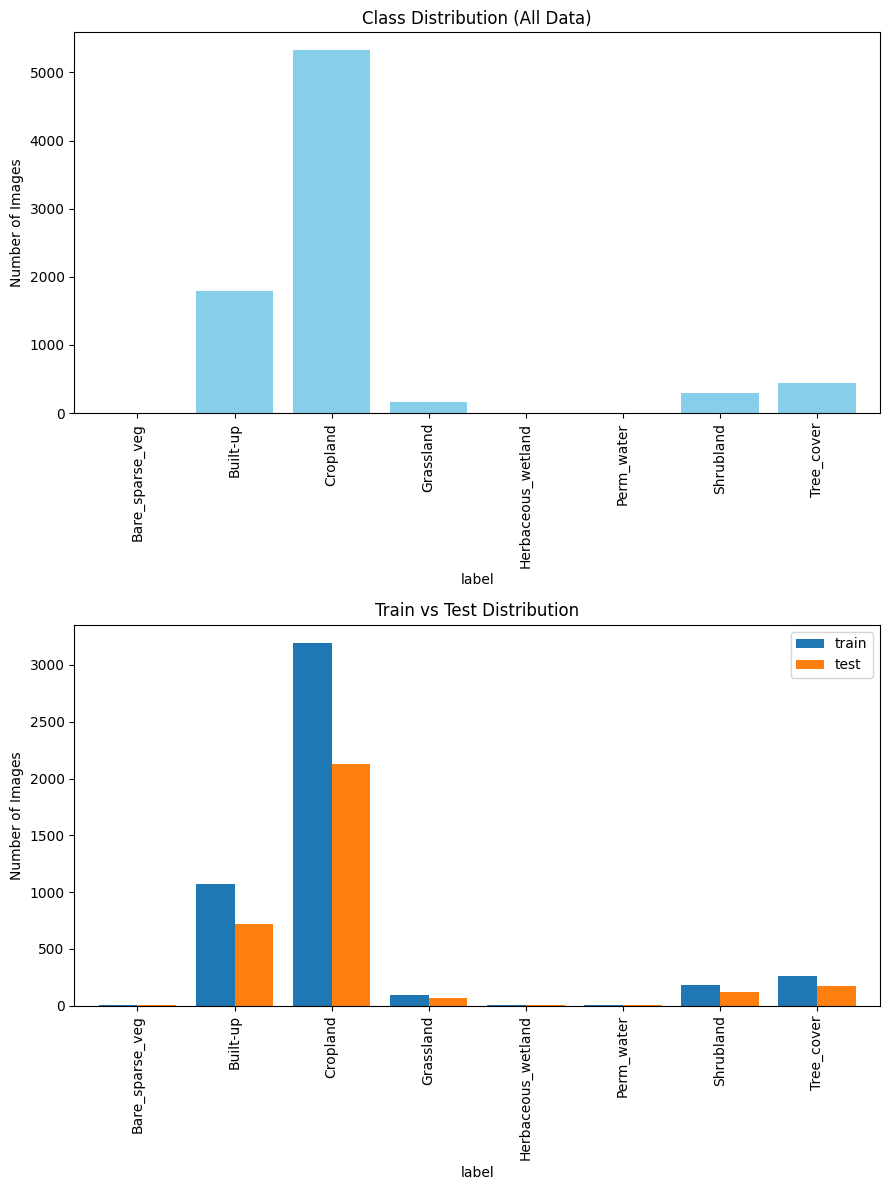

In [201]:
fig, axes = plt.subplots(2, 1, figsize=(9,12))

counts_all = df_labels["label"].value_counts().sort_index()
counts_all.plot(kind="bar", ax=axes[0], width=0.8, color="skyblue")

axes[0].set_title("Class Distribution (All Data)")
axes[0].set_ylabel("Number of Images")

train_counts = train_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

combined = pd.DataFrame({
    "train": train_counts,
    "test": test_counts
}).fillna(0)

combined.plot(kind="bar", ax=axes[1], width=0.8)

axes[1].set_title("Train vs Test Distribution")
axes[1].set_ylabel("Number of Images")

plt.tight_layout()
plt.show()